# Step 5.2 - Clustering: DBSCAN

**Goal:** Apply DBSCAN as a density-based alternative to K-Means and compare results.

**Why DBSCAN after K-Means?**  
K-Means assumes spherical, roughly equal-sized clusters and requires k as input. DBSCAN makes neither assumption: it discovers clusters of arbitrary shape and size, and labels low-density regions as noise (label -1). Given the low K-Means silhouette scores (0.18 for TF-IDF, 0.11 for Word2Vec), DBSCAN lets us test whether the weak cluster structure is due to K-Means assumptions rather than the data itself.

**Key parameters:**
- `eps` (epsilon): neighbourhood radius. Points within eps of each other are density-connected.
- `min_samples`: minimum points in an eps-neighbourhood to form a core point.

**Tuning strategy:** k-distance plot (also called elbow plot for DBSCAN). For each point, compute the distance to its k-th nearest neighbour. Sorting these distances and plotting them reveals a knee: below the knee = dense core regions, above = noise. The knee value is the recommended eps.

## 1. Setup

In [49]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os

PCA_TFIDF_PATH     = "../data/processed/pca_tfidf_50.npy"
PCA_W2V_PATH       = "../data/processed/pca_w2v_50.npy"
CLEAN_DATA_PATH    = "../data/processed/sgbs_clean.csv"

LABELS_DBSCAN_TFIDF_PATH = "../data/processed/dbscan_labels_tfidf.npy"
LABELS_DBSCAN_W2V_PATH   = "../data/processed/dbscan_labels_w2v.npy"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

X_tfidf = np.load(PCA_TFIDF_PATH)
X_w2v   = np.load(PCA_W2V_PATH)

df = pd.read_csv(CLEAN_DATA_PATH)

HAUPTGRUPPEN = {
    '1': 'Staatsrecht/Org.',
    '2': 'Zivilrecht/Strafrecht',
    '3': 'Gesundheit',
    '4': 'Erziehung/Wiss.',
    '5': 'Polizei/Militaer',
    '6': 'Finanzen/Lieg.',
    '7': 'Bau/Energie/Umwelt',
    '8': 'Arbeit/Soziales',
    '9': 'Wirtschaft/Verkehr',
}
df['hauptgruppe'] = df['systematic_number'].astype(str).str[0]

print(f"TF-IDF PCA:   {X_tfidf.shape}")
print(f"Word2Vec PCA: {X_w2v.shape}")
print(f"Docs:         {len(df)}")

TF-IDF PCA:   (726, 50)
Word2Vec PCA: (726, 50)
Docs:         726


## 2. Tune eps - k-Distance Plot

I use `min_samples=5` as a starting point (standard heuristic: 2 * n_dimensions is too large here; 5 is a common default for medium-sized datasets). The k-distance plot is computed for k = min_samples - 1 = 4.

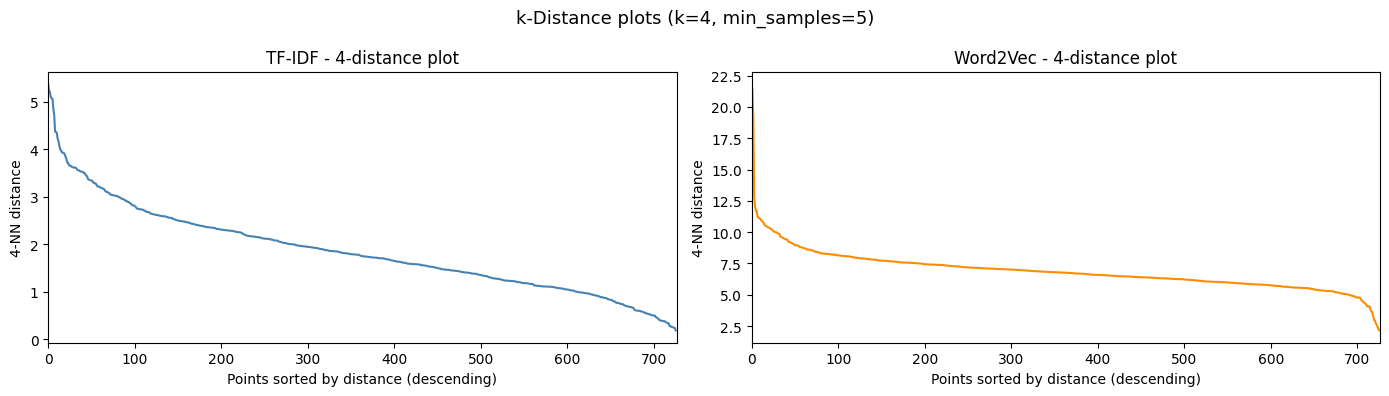

In [50]:
MIN_SAMPLES = 5
K_DIST = MIN_SAMPLES - 1  # k-th nearest neighbour distance

def kdistance_plot(X, k, ax, title, color):
    nn = NearestNeighbors(n_neighbors=k + 1)  # +1 because point itself is included
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    kth_distances = np.sort(distances[:, k])[::-1]  # k-th neighbour, sorted descending
    ax.plot(kth_distances, color=color)
    ax.set_title(f"{title} - {k}-distance plot")
    ax.set_xlabel("Points sorted by distance (descending)")
    ax.set_ylabel(f"{k}-NN distance")
    ax.set_xlim(0, len(kth_distances))
    return kth_distances

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
kd_tfidf = kdistance_plot(X_tfidf, K_DIST, axes[0], "TF-IDF",   "steelblue")
kd_w2v   = kdistance_plot(X_w2v,   K_DIST, axes[1], "Word2Vec",  "darkorange")

plt.suptitle(f"k-Distance plots (k={K_DIST}, min_samples={MIN_SAMPLES})", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_2_dbscan_kdist.png", dpi=150)
plt.show()


## 3. Grid Search over eps

Rather than guessing eps from the k-distance plot alone, I sweep a range of eps values and observe the number of clusters and noise points. A good eps produces a meaningful number of clusters (comparable to the domain structure) with a tolerable noise fraction.

In [51]:
def dbscan_sweep(X, eps_values, min_samples, label):
    print(f"{'eps':>8}  {'clusters':>8}  {'noise':>6}  {'noise%':>7}  {'silhouette':>11}")
    results = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        lbl = db.fit_predict(X)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise    = (lbl == -1).sum()
        noise_pct  = n_noise / len(lbl) * 100
        if n_clusters >= 2 and n_noise < len(lbl):
            sil = silhouette_score(X, lbl)
        else:
            sil = float('nan')
        print(f"{eps:8.3f}  {n_clusters:8d}  {n_noise:6d}  {noise_pct:6.1f}%  {sil:11.4f}")
        results.append((eps, n_clusters, n_noise, noise_pct, sil, lbl))
    return results

# eps ranges derived from k-distance plot percentiles above
eps_tfidf = np.round(np.linspace(
    np.percentile(kd_tfidf, 5),
    np.percentile(kd_tfidf, 85),
    16
), 3)

eps_w2v = np.round(np.linspace(
    np.percentile(kd_w2v, 5),
    np.percentile(kd_w2v, 85),
    16
), 3)

print("=== TF-IDF ===")
res_tfidf = dbscan_sweep(X_tfidf, eps_tfidf, MIN_SAMPLES, "TF-IDF")

print("\n=== Word2Vec ===")
res_w2v = dbscan_sweep(X_w2v, eps_w2v, MIN_SAMPLES, "Word2Vec")

=== TF-IDF ===
     eps  clusters   noise   noise%   silhouette
   0.563         2     678    93.4%      -0.2406
   0.708         2     656    90.4%      -0.2016
   0.852         2     628    86.5%      -0.1594
   0.996         3     585    80.6%      -0.1419
   1.141         3     516    71.1%      -0.0469
   1.285         2     475    65.4%       0.0160
   1.429         3     420    57.9%       0.0674
   1.574         3     363    50.0%       0.1171
   1.718         5     313    43.1%       0.0737
   1.862         3     260    35.8%       0.1941
   2.007         3     206    28.4%       0.2309
   2.151         5     161    22.2%       0.1979
   2.295         2     124    17.1%       0.2891
   2.440         2     100    13.8%       0.3105
   2.584         2      77    10.6%       0.3357
   2.728         2      62     8.5%       0.3515

=== Word2Vec ===
     eps  clusters   noise   noise%   silhouette
   5.018        13     642    88.4%      -0.1538
   5.222        16     613    84.4% 

## 4. Select eps and Run Final DBSCAN


In [52]:
EPS_TFIDF = 2.151   # 5 clusters; silhouette 0.198; 22.2% noise -- chosen for richer comparison with 9 Hauptgruppen
EPS_W2V   = 6.652   # 7 clusters; silhouette -0.107; 26.2% noise -- chosen for richer comparison with 9 Hauptgruppen

db_tfidf = DBSCAN(eps=EPS_TFIDF, min_samples=MIN_SAMPLES)
labels_dbscan_tfidf = db_tfidf.fit_predict(X_tfidf)

db_w2v = DBSCAN(eps=EPS_W2V, min_samples=MIN_SAMPLES)
labels_dbscan_w2v = db_w2v.fit_predict(X_w2v)

for name, labels, X, eps_val in [
    ("TF-IDF",   labels_dbscan_tfidf, X_tfidf, EPS_TFIDF),
    ("Word2Vec", labels_dbscan_w2v,   X_w2v,   EPS_W2V),
]:
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    sil = silhouette_score(X, labels) if n_clusters >= 2 else float('nan')
    print(f"{name:10s}  eps={eps_val:.3f}  "
          f"clusters={n_clusters}  noise={n_noise} ({n_noise/len(labels)*100:.1f}%)  "
          f"silhouette={sil:.4f}")

TF-IDF      eps=2.151  clusters=5  noise=161 (22.2%)  silhouette=0.1979
Word2Vec    eps=6.652  clusters=7  noise=190 (26.2%)  silhouette=-0.1072


## 5. Cluster Size Distribution (incl. noise)

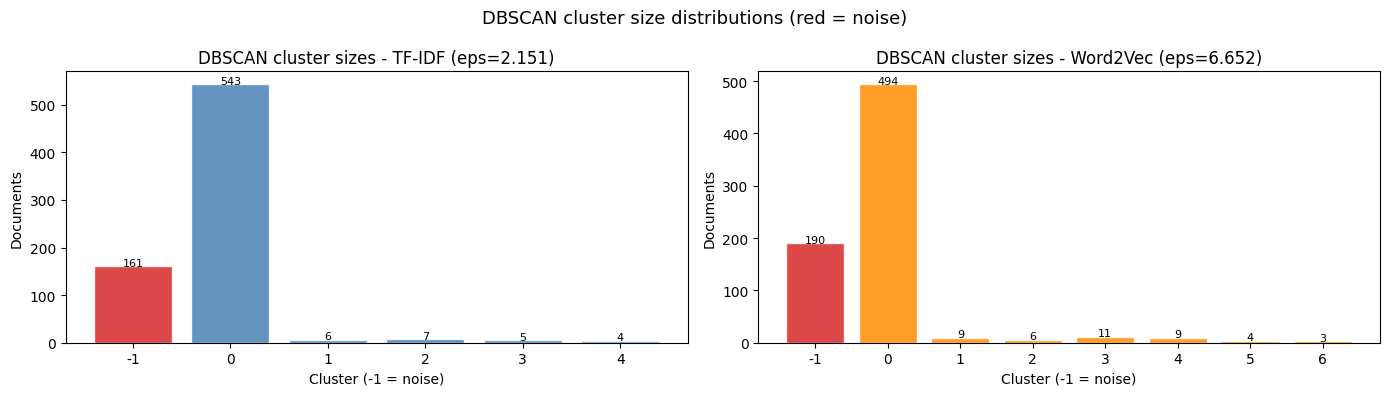

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, labels, title, color in [
    (axes[0], labels_dbscan_tfidf, f"TF-IDF (eps={EPS_TFIDF:.3f})",  "steelblue"),
    (axes[1], labels_dbscan_w2v,   f"Word2Vec (eps={EPS_W2V:.3f})",   "darkorange"),
]:
    counts = pd.Series(labels).value_counts().sort_index()
    bar_colors = ["#d62728" if i == -1 else color for i in counts.index]
    ax.bar([str(i) for i in counts.index], counts.values,
           color=bar_colors, edgecolor="white", alpha=0.85)
    ax.set_title(f"DBSCAN cluster sizes - {title}")
    ax.set_xlabel("Cluster (-1 = noise)")
    ax.set_ylabel("Documents")
    for xi, v in enumerate(counts.values):
        ax.text(xi, v + 1, str(v), ha="center", fontsize=8)

plt.suptitle("DBSCAN cluster size distributions (red = noise)", fontsize=13)
plt.tight_layout()
plt.savefig("../report/figures/05_2_dbscan_sizes.png", dpi=150)
plt.show()

## 6. External Validation: DBSCAN Cluster vs. Hauptgruppen

ARI and NMI are computed on non-noise points only. Noise points (-1) are excluded because they have no cluster assignment and would distort both metrics.

In [57]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

hg_int = pd.factorize(df['hauptgruppe'])[0]

for name, labels in [("TF-IDF DBSCAN", labels_dbscan_tfidf), ("Word2Vec DBSCAN", labels_dbscan_w2v)]:
    core = labels != -1
    if core.sum() < 2:
        print(f"{name}: too few non-noise points")
        continue
    ari = adjusted_rand_score(hg_int[core], labels[core])
    nmi = normalized_mutual_info_score(hg_int[core], labels[core])
    print(f"{name}: ARI={ari:.3f}, NMI={nmi:.3f}")

TF-IDF DBSCAN: ARI=-0.002, NMI=0.066
Word2Vec DBSCAN: ARI=0.010, NMI=0.134


## 7. Persist

In [58]:
np.save(LABELS_DBSCAN_TFIDF_PATH, labels_dbscan_tfidf)
np.save(LABELS_DBSCAN_W2V_PATH,   labels_dbscan_w2v)
print("Saved DBSCAN labels.")

Saved DBSCAN labels.
